In [1]:
import pandas as pd
import numpy as np
from linearmodels.panel import PanelOLS
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.iolib.summary2 import summary_col

最标准的双边固定+时间固定

读取数据并调整顺序

In [2]:
# 读取数据
model_data_path = '../data/processed/merged_dataset_cleaned.csv'
model_df = pd.read_csv(model_data_path)

def add_interaction_terms(df, spei_lag_var):
    """
    添加 SPEI 滞后变量的交互项。
    
    Parameters:
    df: pd.DataFrame
        数据框
    spei_lag_var: str
        SPEI 滞后变量的列名
    
    Returns:
    pd.DataFrame
        添加交互项后的数据框
    """
    df['spei_ma_interact'] = df[spei_lag_var] * df['o_MA']
    df['spei_bf_interact'] = df[spei_lag_var] * df['border_friction_ij']
    return df

model_df = add_interaction_terms(model_df, 'spei_lag3')



In [3]:
# 按照指定顺序调整列顺序
ordered_columns = [
    # ISO 列
    'origin_iso3', 'destination_iso3',
    # 日期相关
    'migration_date', 'year', 'month',
    # 因变量
    'flow', 'log_flow',
    # 重点自变量
    'o_spei', 'spei_lag1', 'spei_lag2', 'spei_lag3', 'o_MA', 'border_friction_ij',
    # 交互项
    'spei_ma_interact', 'spei_bf_interact',
    # 控制变量
    'o_gdp_pc', 'd_gdp_pc', 'o_pop', 'd_pop', 'o_urban', 'd_urban',
    'o_unemp', 'd_unemp', 'o_political_stability', 'd_political_stability',
    'control_distwces',
    # 其他变量
    'spei_date', 'drought_category',
    'o_gdp_pc_was_missing', 'd_gdp_pc_was_missing', 'o_unemp_was_missing', 'd_unemp_was_missing',
    'o_pop_was_missing', 'd_pop_was_missing', 'o_urban_was_missing', 'd_urban_was_missing',
    'o_political_stability_was_missing', 'd_political_stability_was_missing'
]

# 重新排列列顺序
model_df = model_df[ordered_columns]

#### 1. 数据质量检查

#####  检查是否还有缺失值

In [4]:
print(model_df.isnull().sum())

origin_iso3                          0
destination_iso3                     0
migration_date                       0
year                                 0
month                                0
flow                                 0
log_flow                             0
o_spei                               0
spei_lag1                            0
spei_lag2                            0
spei_lag3                            0
o_MA                                 0
border_friction_ij                   0
spei_ma_interact                     0
spei_bf_interact                     0
o_gdp_pc                             0
d_gdp_pc                             0
o_pop                                0
d_pop                                0
o_urban                              0
d_urban                              0
o_unemp                              0
d_unemp                              0
o_political_stability                0
d_political_stability                0
control_distwces         

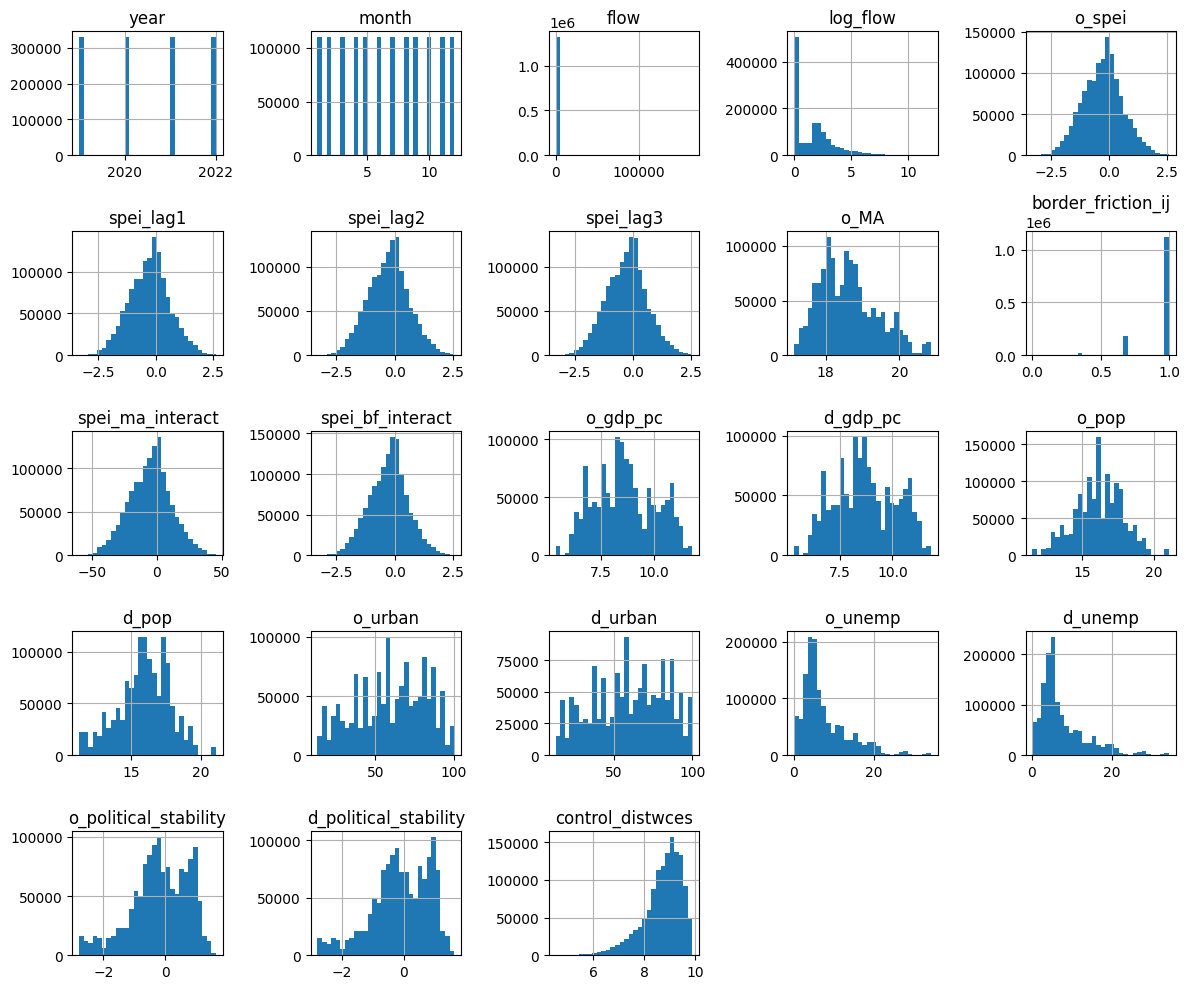

In [5]:
# 检查数据分布和异常值
valuable_columns = [
    'year',
    'month',
    'flow',  # 迁移流
    'log_flow',  # 迁移流的对数值
    'o_spei',  # 干旱指数
    'spei_lag1',  # 干旱指数滞后一期
    'spei_lag2',  # 干旱指数滞后两期
    'spei_lag3',  # 干旱指数滞后三期
    'o_MA',  # Market Access
    'border_friction_ij',  # 边境摩擦
    'spei_ma_interact',  # 干旱指数与市场接入的交互项
    'spei_bf_interact',  # 干旱指数与边境摩擦的交互项
    'o_gdp_pc',  # 出发国 GDP per capita
    'd_gdp_pc',  # 目的国 GDP per capita
    'o_pop',  # 出发国人口
    'd_pop',  # 目的国人口
    'o_urban',  # 出发国城市化率
    'd_urban',  # 目的国城市化率
    'o_unemp',  # 出发国失业率
    'd_unemp',  # 目的国失业率
    'o_political_stability',  # 出发国政治稳定性
    'd_political_stability',  # 目的国政治稳定性
    'control_distwces'  # 控制变量：距离
]

# 绘制选定变量的直方图
model_df[valuable_columns].hist(figsize=(12, 10), bins=30)
plt.tight_layout()
plt.show()

##### 时间变量处理
生成 唯一的时间 ID（方便做时间固定效应）：

In [6]:
# 创建 time_id，从 2019 年开始的连续数字
model_df['time_id'] = (
    (pd.to_datetime(model_df['migration_date']).dt.year - 2019) * 12 +
    pd.to_datetime(model_df['migration_date']).dt.month
)

##### 3. 双边 ID 创建
固定效应要区分国家对：

In [7]:
# 创建双边 ID（数字形式）
model_df['pair_id'] = model_df.groupby(['origin_iso3', 'destination_iso3']).ngroup()

In [8]:
model_df

,origin_iso3,destination_iso3,migration_date,year,month,flow,log_flow,o_spei,spei_lag1,spei_lag2,...,o_unemp_was_missing,d_unemp_was_missing,o_pop_was_missing,d_pop_was_missing,o_urban_was_missing,d_urban_was_missing,o_political_stability_was_missing,d_political_stability_was_missing,time_id,pair_id
0,ARE,AND,2019-01-01,2019,1,0,0.000000,0.013769,0.345254,-0.196752,...,0,1,0,0,0,0,0,1,1,522
1,ARE,AND,2019-02-01,2019,2,12,2.564949,-0.017917,0.013769,0.345254,...,0,1,0,0,0,0,0,1,2,522
2,ARE,AND,2019-03-01,2019,3,0,0.000000,0.490999,-0.017917,0.013769,...,0,1,0,0,0,0,0,1,3,522
3,ARE,AND,2019-04-01,2019,4,1,0.693147,0.797000,0.490999,-0.017917,...,0,1,0,0,0,0,0,1,4,522
4,ARE,AND,2019-05-01,2019,5,3,1.386294,0.580897,0.797000,0.490999,...,0,1,0,0,0,0,0,1,5,522
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1319781,ZWE,ZMB,2022-08-01,2022,8,138,4.934474,0.326137,0.494725,0.959915,...,0,0,0,0,0,0,0,0,44,27496
1319782,ZWE,ZMB,2022-09-01,2022,9,162,5.093750,-0.502948,0.326137,0.494725,...,0,0,0,0,0,0,0,0,45,27496
1319783,ZWE,ZMB,2022-10-01,2022,10,149,5.010635,-0.593602,-0.502948,0.326137,...,0,0,0,0,0,0,0,0,46,27496
1319784,ZWE,ZMB,2022-11-01,2022,11,104,4.653960,-0.331173,-0.593602,-0.502948,...,0,0,0,0,0,0,0,0,47,27496


In [9]:
print(model_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1319786 entries, 0 to 1319785
Data columns (total 40 columns):
 #   Column                             Non-Null Count    Dtype  
---  ------                             --------------    -----  
 0   origin_iso3                        1319786 non-null  object 
 1   destination_iso3                   1319786 non-null  object 
 2   migration_date                     1319786 non-null  object 
 3   year                               1319786 non-null  int64  
 4   month                              1319786 non-null  int64  
 5   flow                               1319786 non-null  int64  
 6   log_flow                           1319786 non-null  float64
 7   o_spei                             1319786 non-null  float64
 8   spei_lag1                          1319786 non-null  float64
 9   spei_lag2                          1319786 non-null  float64
 10  spei_lag3                          1319786 non-null  float64
 11  o_MA                    

#### 2. 探索性数据分析 (EDA)
通过可视化和统计分析，了解数据的基本特征：

<Axes: title={'center': 'Yearly Migration Flow'}, xlabel='year'>

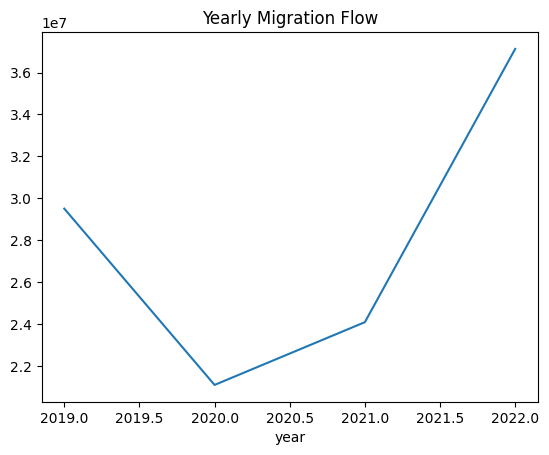

In [10]:
model_df.groupby('year')['flow'].sum().plot(kind='line', title='Yearly Migration Flow')

##### 相关性分析：检查变量之间的相关性

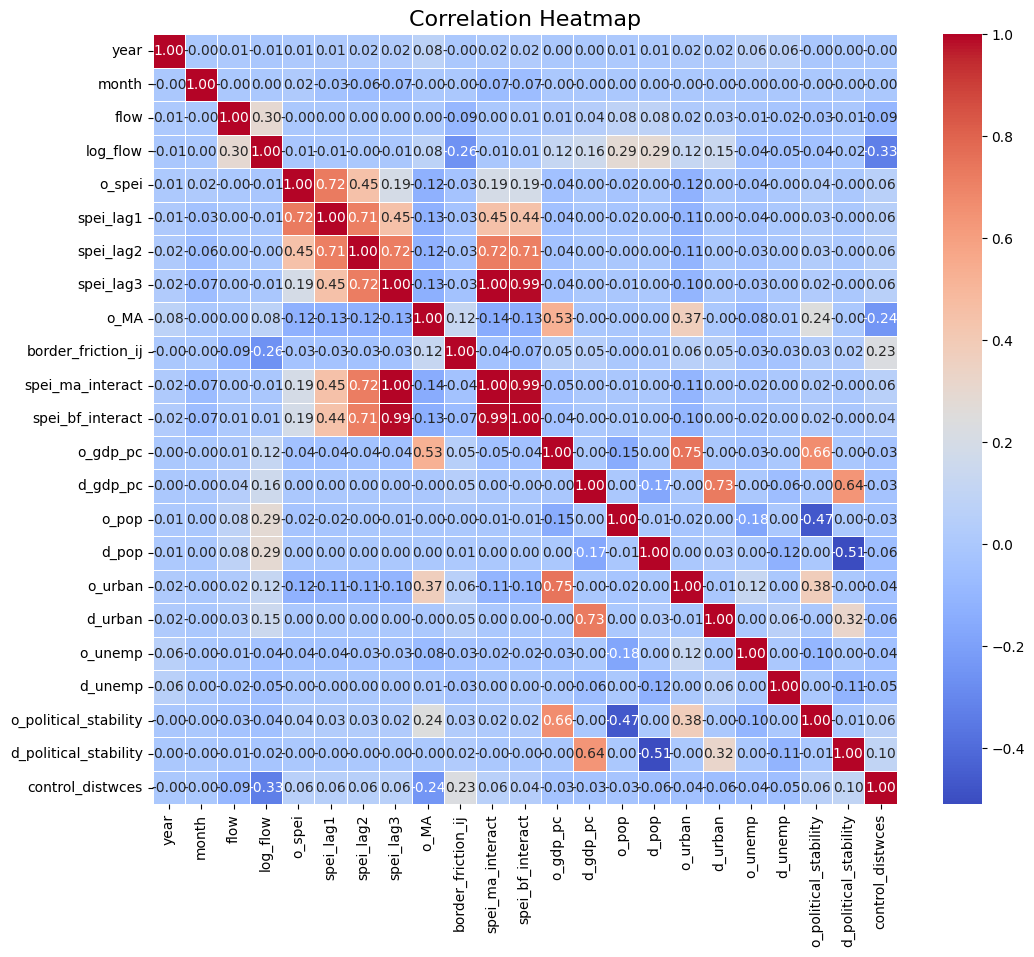

In [11]:
# 过滤掉包含 'xxx_was_missing' 的列和两个 ID 列
exclude_columns = ['pair_id', 'time_id']  # 两个 ID 列
numeric_cols = model_df.select_dtypes(include=[np.number])
filtered_cols = [col for col in numeric_cols.columns if 'was_missing' not in col and col not in exclude_columns]

# 只选择数值列
corr = numeric_cols[filtered_cols].select_dtypes(include=[np.number]).corr()

# 绘制热力图，调整图表大小
plt.figure(figsize=(12, 10))  # 调整宽度和高度
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

#### 3. 模型搭建

In [12]:
# === 数据准备 ===
# 确保数据是多重索引格式（PanelOLS 需要）
model_df = model_df.set_index(['pair_id', 'time_id']).sort_index()


##### 模型定义

In [13]:
# 控制变量
controls = [
    'o_gdp_pc', 'd_gdp_pc',
    'o_pop', 'd_pop',
    'o_urban', 'd_urban',
    'o_unemp', 'd_unemp',
    'o_political_stability', 'd_political_stability',
    'control_distwces'
]

#### 不同的归回模型设定

双边固定+时间固定

In [18]:
# Baseline 模型
baseline_formula = (
    'log_flow ~ spei_lag3 + ' + ' + '.join(controls) + ' + EntityEffects + TimeEffects'
    )

# 模型 2：+ o_MA 和交互项
model_5_formula = ('log_flow ~ spei_lag3 + o_MA + spei_ma_interact + ' + ' + '.join(controls) + ' + EntityEffects + TimeEffects')

# 模型 3：+ border_friction_ij 和交互项
model_6_formula = ('log_flow ~ spei_lag3 + border_friction_ij + spei_bf_interact + ' + ' + '.join(controls) + ' + EntityEffects + TimeEffects')

# 模型 4：完整模型
model_7_formula = (
    'log_flow ~ spei_lag3 + o_MA + border_friction_ij + '
    'spei_ma_interact + spei_bf_interact + '
    + ' + '.join(controls) + ' + EntityEffects + TimeEffects'
)

修改双边固定为起源国+目的国+时间固定效应


In [19]:
# # 修改后的模型公式
# baseline_formula = (
#     'log_flow ~ spei_lag1 + ' + ' + '.join(controls) + ' + C(origin_iso3) + C(destination_iso3) + TimeEffects'
# )

# model_2_formula = (
#     'log_flow ~ spei_lag1 + o_MA + spei_ma_interact + ' + ' + '.join(controls) + ' + C(origin_iso3) + C(destination_iso3) + TimeEffects'
# )

# model_3_formula = (
#     'log_flow ~ spei_lag1 + border_friction_ij + spei_bf_interact + ' + ' + '.join(controls) + ' + C(origin_iso3) + C(destination_iso3) + TimeEffects'
# )

# model_4_formula = (
#     'log_flow ~ spei_lag1 + o_MA + border_friction_ij + '
#     'spei_ma_interact + spei_bf_interact + '
#     + ' + '.join(controls) + ' + C(origin_iso3) + C(destination_iso3) + TimeEffects'
# )

In [20]:
# 运行回归
models = {}
for name, formula in zip(
    ['Model 4', 'Model 5', 'Model 6', 'Model 7'],
    [baseline_formula, model_5_formula, model_6_formula, model_7_formula]
):
    models[name] = PanelOLS.from_formula(
        formula,
        data=model_df,
        drop_absorbed=True
    ).fit(
        cov_type='clustered',        # 聚类标准误
        cluster_entity=True          # 在实体（pair）层面聚类
    )


C:\Users\cmy\AppData\Local\Temp\ipykernel_36628\1204479931.py:11: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

control_distwces

  ).fit(
C:\Users\cmy\AppData\Local\Temp\ipykernel_36628\1204479931.py:11: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

control_distwces

  ).fit(
C:\Users\cmy\AppData\Local\Temp\ipykernel_36628\1204479931.py:11: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

border_friction_ij, control_distwces

  ).fit(
C:\Users\cmy\AppData\Local\Temp\ipykernel_36628\1204479931.py:11: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

border_friction_ij, control_distwces

  ).fit(


In [21]:
# === 输出回归结果 ===
# 打印每个模型的回归结果
for name, model in models.items():
    print(f"=== {name} ===")
    print(model.summary)

=== Model 4 ===
                          PanelOLS Estimation Summary                           
Dep. Variable:               log_flow   R-squared:                        0.0007
Estimator:                   PanelOLS   R-squared (Between):             -54.873
No. Observations:             1319786   R-squared (Within):               0.0003
Date:                Fri, Aug 15 2025   R-squared (Overall):             -45.926
Time:                        06:18:28   Log-likelihood                -1.854e+06
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      77.310
Entities:                       27497   P-value                           0.0000
Avg Obs:                       47.997   Distribution:              F(11,1292231)
Min Obs:                       22.000                                           
Max Obs:                       48.000   F-statistic (robust):             34.034
            

边际效应

小表:
   ln(MA) 分位点  ln(MA) 数值  边际效应：∂lnM/∂SPEI  \
0         0.1  -0.051213        -0.037217   
1         0.5  -0.003365        -0.037141   
2         0.9   0.062665        -0.037035   

                                        95% CI       p 值  换算：干旱恶化 1SD 的 %Δ流量  
0  (-0.09579832127684876, 0.02136384955050296)  0.213054            3.273644  
1  (-0.0955729857886457, 0.021291612053000654)  0.212833            3.266802  
2  (-0.09526203385507837, 0.02119192876161436)  0.212526            3.257361  


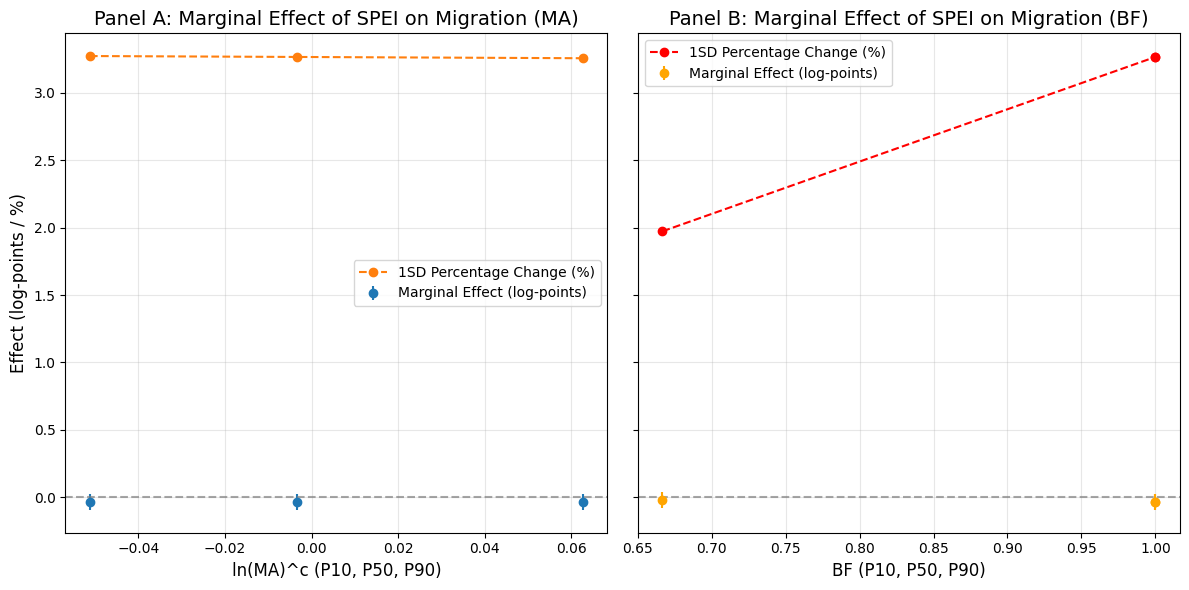

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# 提取 Model 7 的系数和协方差矩阵
model_7 = models["Model 7"]
beta_1 = model_7.params['spei_lag3']
beta_2 = model_7.params['spei_ma_interact']
beta_3 = model_7.params['spei_bf_interact']
cov_matrix = model_7.cov

# 计算 SPEI 的标准差
spei_sd = model_df['spei_lag3'].std()

# 计算 ln(MA) 和 BF 的 P10/P50/P90
ln_ma = np.log(model_df['o_MA'])
ln_ma_centered = ln_ma - ln_ma.mean()  # 去均值
bf = model_df['border_friction_ij']
ln_ma_quantiles = ln_ma_centered.quantile([0.1, 0.5, 0.9])
bf_quantiles = bf.quantile([0.1, 0.5, 0.9])

# 计算边际效应和置信区间
def compute_marginal_effect_with_ci(z, fixed_bf=None):
    if fixed_bf is None:
        fixed_bf = bf.median()
    me = beta_1 + beta_2 * z + beta_3 * fixed_bf
    var_me = (
        cov_matrix.loc['spei_lag3', 'spei_lag3'] +
        z**2 * cov_matrix.loc['spei_ma_interact', 'spei_ma_interact'] +
        fixed_bf**2 * cov_matrix.loc['spei_bf_interact', 'spei_bf_interact'] +
        2 * z * cov_matrix.loc['spei_lag3', 'spei_ma_interact'] +
        2 * fixed_bf * cov_matrix.loc['spei_lag3', 'spei_bf_interact'] +
        2 * z * fixed_bf * cov_matrix.loc['spei_ma_interact', 'spei_bf_interact']
    )
    se_me = np.sqrt(var_me)
    ci_lower = me - 1.96 * se_me
    ci_upper = me + 1.96 * se_me
    p_value = 2 * (1 - stats.norm.cdf(abs(me / se_me)))
    percent_change = (np.exp(me * -spei_sd) - 1) * 100
    return me, (ci_lower, ci_upper), p_value, percent_change

# 生成小表
rows = []
for quantile, z in ln_ma_quantiles.items():
    me, ci, p_value, percent_change = compute_marginal_effect_with_ci(z)
    rows.append({
        "ln(MA) 分位点": quantile,
        "ln(MA) 数值": z,
        "边际效应：∂lnM/∂SPEI": me,
        "95% CI": ci,
        "p 值": p_value,
        "换算：干旱恶化 1SD 的 %Δ流量": percent_change
    })

# 转换为 DataFrame
marginal_effects_table = pd.DataFrame(rows)

# 打印小表
print("小表:")
print(marginal_effects_table)

# === 绘制边际效应图 ===
# 计算 MA 和 BF 的边际效应
ma_effects = [compute_marginal_effect_with_ci(z, fixed_bf=bf.median()) for z in ln_ma_quantiles]
ma_me_values = [effect[0] for effect in ma_effects]
ma_ci_values = [effect[1] for effect in ma_effects]
ma_percent_change = [effect[3] for effect in ma_effects]

bf_effects = [compute_marginal_effect_with_ci(ln_ma_centered.median(), fixed_bf=z) for z in bf_quantiles]
bf_me_values = [effect[0] for effect in bf_effects]
bf_ci_values = [effect[1] for effect in bf_effects]
bf_percent_change = [effect[3] for effect in bf_effects]

# 绘制分面图
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Panel A: MA 的边际效应
axes[0].errorbar(ln_ma_quantiles.values, ma_me_values, 
                 yerr=[np.abs(np.array(ma_me_values) - np.array([ci[0] for ci in ma_ci_values])),
                       np.abs(np.array([ci[1] for ci in ma_ci_values]) - np.array(ma_me_values))],
                 fmt='o', label='Marginal Effect (log-points)')
axes[0].plot(ln_ma_quantiles.values, ma_percent_change, marker='o', linestyle='--', label='1SD Percentage Change (%)')
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.7)
axes[0].set_title("Panel A: Marginal Effect of SPEI on Migration (MA)", fontsize=14)
axes[0].set_xlabel("ln(MA)^c (P10, P50, P90)", fontsize=12)
axes[0].set_ylabel("Effect (log-points / %)", fontsize=12)
axes[0].grid(alpha=0.3)
axes[0].legend()

# Panel B: BF 的边际效应
axes[1].errorbar(bf_quantiles.values, bf_me_values, 
                 yerr=[np.abs(np.array(bf_me_values) - np.array([ci[0] for ci in bf_ci_values])),
                       np.abs(np.array([ci[1] for ci in bf_ci_values]) - np.array(bf_me_values))],
                 fmt='o', label='Marginal Effect (log-points)', color='orange')
axes[1].plot(bf_quantiles.values, bf_percent_change, marker='o', linestyle='--', label='1SD Percentage Change (%)', color='red')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.7)
axes[1].set_title("Panel B: Marginal Effect of SPEI on Migration (BF)", fontsize=14)
axes[1].set_xlabel("BF (P10, P50, P90)", fontsize=12)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [23]:
print("Model MA结果:")
print(f"spei_lag3: {model_7.params['spei_lag3']}")
print(f"spei_lag3:o_MA: {model_7.params['spei_ma_interact']}")

print("Model BF结果:")
print(f"spei_lag3: {model_7.params['spei_lag3']}")
print(f"spei_lag3:border_friction_ij: {model_7.params['spei_bf_interact']}")

Model MA结果:
spei_lag3: 0.006570983759652208
spei_lag3:o_MA: 0.0015998114658705932
Model BF结果:
spei_lag3: 0.006570983759652208
spei_lag3:border_friction_ij: -0.04370628794489448


#### 用Dry=-spei再次检验（Model 8）

C:\Users\cmy\AppData\Local\Temp\ipykernel_36628\2076156979.py:16: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

border_friction_ij, control_distwces

  ).fit(


=== Model 8 ===
                          PanelOLS Estimation Summary                           
Dep. Variable:               log_flow   R-squared:                        0.0007
Estimator:                   PanelOLS   R-squared (Between):             -52.737
No. Observations:             1319786   R-squared (Within):               0.0003
Date:                Fri, Aug 15 2025   R-squared (Overall):             -44.138
Time:                        06:19:42   Log-likelihood                -1.853e+06
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      62.855
Entities:                       27497   P-value                           0.0000
Avg Obs:                       47.997   Distribution:              F(14,1292228)
Min Obs:                       22.000                                           
Max Obs:                       48.000   F-statistic (robust):             28.519
            

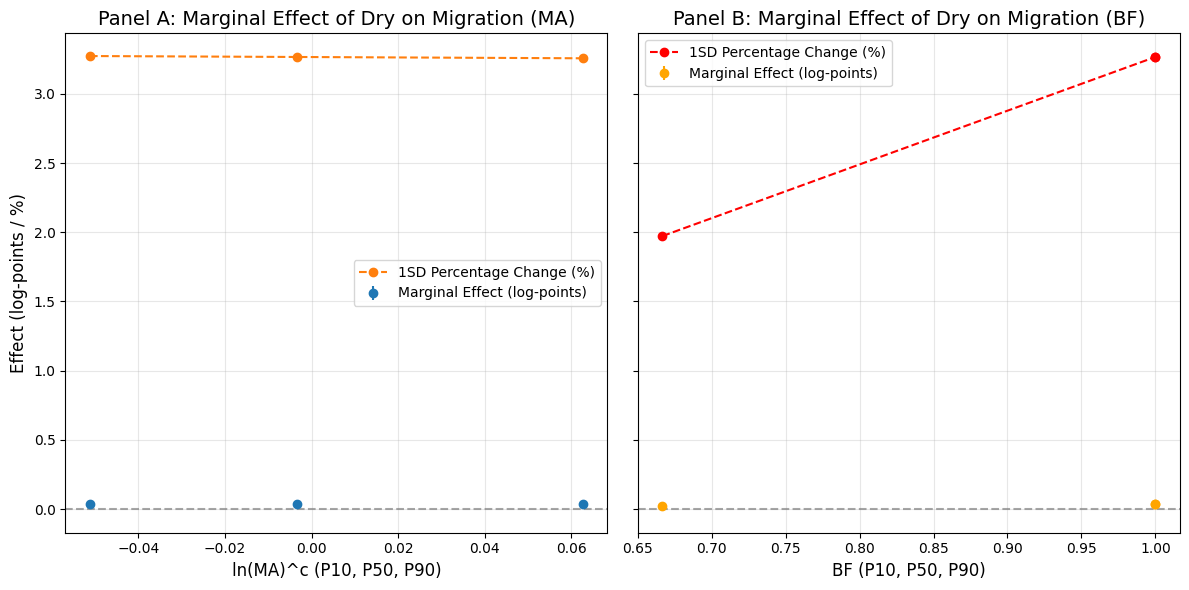

In [24]:
# === 1. 添加 Dry 变量 ===
model_df['Dry'] = -model_df['spei_lag3']

# === 2. 定义 Model 8 ===
model_8_formula = (
    'log_flow ~ Dry + o_MA + border_friction_ij + '
    'Dry:o_MA + Dry:border_friction_ij + '
    + ' + '.join(controls) + ' + EntityEffects + TimeEffects'
)

# === 3. 估计 Model 8 ===
model_8 = PanelOLS.from_formula(
    model_8_formula,
    data=model_df,
    drop_absorbed=True
).fit(
    cov_type='clustered',
    cluster_entity=True
)

# 打印 Model 8 的回归结果
print("=== Model 8 ===")
print(model_8.summary)

# === 4. 计算边际效应 ===
# 提取 Model 8 的系数
beta_dry = model_8.params['Dry']
beta_dry_ma = model_8.params['Dry:o_MA']
beta_dry_bf = model_8.params['Dry:border_friction_ij']
cov_matrix_8 = model_8.cov

# 计算边际效应和置信区间
def compute_marginal_effect_dry(z, fixed_bf=None):
    if fixed_bf is None:
        fixed_bf = bf.median()
    me = beta_dry + beta_dry_ma * z + beta_dry_bf * fixed_bf
    var_me = (
        cov_matrix_8.loc['Dry', 'Dry'] +
        z**2 * cov_matrix_8.loc['Dry:o_MA', 'Dry:o_MA'] +
        fixed_bf**2 * cov_matrix_8.loc['Dry:border_friction_ij', 'Dry:border_friction_ij'] +
        2 * z * cov_matrix_8.loc['Dry', 'Dry:o_MA'] +
        2 * fixed_bf * cov_matrix_8.loc['Dry', 'Dry:border_friction_ij'] +
        2 * z * fixed_bf * cov_matrix_8.loc['Dry:o_MA', 'Dry:border_friction_ij']
    )
    se_me = np.sqrt(var_me)
    return me, se_me

# 计算 MA 方向的边际效应和置信区间
ma_effects_dry = [compute_marginal_effect_dry(z, fixed_bf=bf.median()) for z in ln_ma_quantiles]
ma_me_values_dry = [effect[0] for effect in ma_effects_dry]
ma_se_values_dry = [effect[1] for effect in ma_effects_dry]
ma_percent_change_dry = [(np.exp(me * spei_sd) - 1) * 100 for me in ma_me_values_dry]

# 计算 BF 方向的边际效应和置信区间
bf_effects_dry = [compute_marginal_effect_dry(ln_ma_centered.median(), fixed_bf=z) for z in bf_quantiles]
bf_me_values_dry = [effect[0] for effect in bf_effects_dry]
bf_se_values_dry = [effect[1] for effect in bf_effects_dry]
bf_percent_change_dry = [(np.exp(me * spei_sd) - 1) * 100 for me in bf_me_values_dry]

# === 5. 绘制边际效应图 ===
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# Panel A: MA 的边际效应
axes[0].errorbar(ln_ma_quantiles.values, ma_me_values_dry, yerr=ma_se_values_dry, fmt='o', label='Marginal Effect (log-points)')
axes[0].plot(ln_ma_quantiles.values, ma_percent_change_dry, marker='o', linestyle='--', label='1SD Percentage Change (%)')
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.7)
axes[0].set_title("Panel A: Marginal Effect of Dry on Migration (MA)", fontsize=14)
axes[0].set_xlabel("ln(MA)^c (P10, P50, P90)", fontsize=12)
axes[0].set_ylabel("Effect (log-points / %)", fontsize=12)
axes[0].grid(alpha=0.3)
axes[0].legend()

# Panel B: BF 的边际效应
axes[1].errorbar(bf_quantiles.values, bf_me_values_dry, yerr=bf_se_values_dry, fmt='o', label='Marginal Effect (log-points)', color='orange')
axes[1].plot(bf_quantiles.values, bf_percent_change_dry, marker='o', linestyle='--', label='1SD Percentage Change (%)', color='red')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.7)
axes[1].set_title("Panel B: Marginal Effect of Dry on Migration (BF)", fontsize=14)
axes[1].set_xlabel("BF (P10, P50, P90)", fontsize=12)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [25]:
# 检查基础系数
β_spei = model_8.params['Dry']
β_spei_ma = model_8.params['Dry:o_MA']
β_spei_bf = model_8.params['Dry:border_friction_ij']

print("=== 基础诊断 ===")
print(f"SPEI主效应: {β_spei}")
print(f"MA交互项: {β_spei_ma}")  
print(f"BF交互项: {β_spei_bf}")
print("")
print("=== 预期符号 ===")
print("SPEI主效应: 应该 < 0")
print("MA交互项: 应该 < 0 (放大负效应)")
print("BF交互项: 应该 > 0 (削弱负效应)")

=== 基础诊断 ===
SPEI主效应: -0.006570983759652198
MA交互项: -0.0015998114658705936
BF交互项: 0.04370628794489448

=== 预期符号 ===
SPEI主效应: 应该 < 0
MA交互项: 应该 < 0 (放大负效应)
BF交互项: 应该 > 0 (削弱负效应)


#### 基准模型+逐步添加控制变量

In [26]:
from linearmodels.panel import PanelOLS

# 定义控制变量
economic_controls = ['o_gdp_pc', 'd_gdp_pc', 'o_pop', 'd_pop']
political_controls = ['o_political_stability', 'd_political_stability']
geographic_controls = ['control_distwces', 'o_urban', 'd_urban', 'o_unemp', 'd_unemp']

# 定义模型公式
model_formulas = {
    "Model 1": "log_flow ~ spei_lag3 + EntityEffects + TimeEffects",
    "Model 2": f"log_flow ~ spei_lag3 + {' + '.join(economic_controls)} + EntityEffects + TimeEffects",
    "Model 3": f"log_flow ~ spei_lag3 + {' + '.join(economic_controls)} + {' + '.join(political_controls)} + EntityEffects + TimeEffects",
    "Model 4": f"log_flow ~ spei_lag3 + {' + '.join(economic_controls)} + {' + '.join(political_controls)} + {' + '.join(geographic_controls)} + EntityEffects + TimeEffects"
}

# 运行回归并记录结果
results = {}
for model_name, formula in model_formulas.items():
    model = PanelOLS.from_formula(formula, data=model_df, drop_absorbed=True).fit(
        cov_type='clustered', cluster_entity=True
    
    )
    results[model_name] = model

# 输出回归结果
for model_name, model in results.items():
    print(f"=== {model_name} ===")
    print(model.summary)

    # 提取 SPEI (lag1) 系数信息
    spei_coeff = model.params['spei_lag3']
    spei_se = model.std_errors['spei_lag3']
    spei_t = model.tstats['spei_lag3']
    spei_p = model.pvalues['spei_lag3']
    significance = "**" if spei_p < 0.05 else "*" if spei_p < 0.1 else ""

    print(f"SPEI (lag1): β₁ = {spei_coeff:.3f}, SE = {spei_se:.3f}, t = {spei_t:.3f}, p = {spei_p:.3f} {significance}")

    # 提取控制变量系数信息
    for control in economic_controls + political_controls + geographic_controls:
        if control in model.params:
            coeff = model.params[control]
            se = model.std_errors[control]
            t = model.tstats[control]
            p = model.pvalues[control]
            significance = "**" if p < 0.05 else "*" if p < 0.1 else ""
            print(f"{control}: β = {coeff:.3f}, SE = {se:.3f}, t = {t:.3f}, p = {p:.3f} {significance}")

    # 输出模型统计信息
    print(f"Observations: {model.nobs}")
    print(f"Number of pairs: {model_df.index.get_level_values('pair_id').nunique()}")
    print(f"R² (within): {model.rsquared:.3f}")
    print(f"R² (overall): {model.rsquared_overall:.3f}")
    print("\n")

C:\Users\cmy\AppData\Local\Temp\ipykernel_36628\1992978604.py:19: AbsorbingEffectWarning: 
Variables have been fully absorbed and have removed from the regression:

control_distwces

  model = PanelOLS.from_formula(formula, data=model_df, drop_absorbed=True).fit(


=== Model 1 ===
                          PanelOLS Estimation Summary                           
Dep. Variable:               log_flow   R-squared:                     1.922e-05
Estimator:                   PanelOLS   R-squared (Between):              0.0010
No. Observations:             1319786   R-squared (Within):            3.299e-06
Date:                Fri, Aug 15 2025   R-squared (Overall):              0.0008
Time:                        06:19:54   Log-likelihood                -1.854e+06
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      24.840
Entities:                       27497   P-value                           0.0000
Avg Obs:                       47.997   Distribution:               F(1,1292241)
Min Obs:                       22.000                                           
Max Obs:                       48.000   F-statistic (robust):             18.263
            

In [27]:
# 计算 SPEI 的标准差
spei_sd = model_df['spei_lag3'].std()
print(f"SPEI 滞后一期的标准差: {spei_sd:.3f}")

# 提取模型 1 的 SPEI 系数
spei_coeff = results["Model 1"].params['spei_lag3']

# 换算经济意义：干旱恶化一个标准差对迁移流的百分比变化
percentage_change = (np.exp(spei_coeff * spei_sd) - 1) * 100
print(f"干旱恶化一个标准差导致迁移流变化: {percentage_change:.2f}%")

SPEI 滞后一期的标准差: 0.866
干旱恶化一个标准差导致迁移流变化: -0.48%
